<center><h2><b>Fall 2026</b><br/>
<b>CSC-372 Project Part 2<br/></h2></b>

# PyTorch: A Modern Deep Learning Library

</center>


<a href="https://colab.research.google.com/github/fahadsultan/csc372/blob/main/Project2.ipynb" target="_blank" align="right">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


[PyTorch](https://pytorch.org/) is arguably the most popular deep learning library in use today. It is an open-source library developed by Facebook’s AI Research lab (FAIR). One of the reasons PyTorch is so popular is its user-friendly interface and efficiency. Despite its accessibility, it doesn’t compromise on flexibility, allowing advanced users to tweak lower-level aspects of their models for customization and optimization. In short, for many practitioners and researchers, PyTorch offers just the right balance between usability and features.

PyTorch is a relatively comprehensive library, and one way to approach it is to focus on its three broad components, summarized in figure below:

<img src="https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/Images/A-1.png" style="filter: invert(1);" width="100%">

<font color="violet">PyTorch's three main components include a <b>tensor library</b> as a fundamental building block for computing, <b>automatic differentiation</b> for model optimization, and <b>deep learning utility functions</b>, making it easier to implement and train deep neural network models</font>.

1. The <font color="violet">**tensor library**</font> extends the concept of the array-oriented programming library NumPy with the additional feature that accelerates computation on GPUs, thus providing a seamless switch between CPUs and GPUs.

2. <font color="violet">**Automatic differentiation engine**</font>, also known as **autograd** enables the automatic computation of gradients for tensor operations, simplifying backpropagation and model optimization.

3. <font color="violet">**Deep learning library**</font> offers modular, flexible, and efficient building blocks, including pretrained models, loss functions, and optimizers, for designing and training a wide range of deep learning models, catering to both researchers and developers.


Pytorch can be installed using pip or conda. The following command installs the latest stable version of PyTorch with CUDA 11.8 support using pip:

```bash
pip install torch
```

After installing PyTorch, you can check whether your installation recognizes your built-in NVIDIA GPU by running the following code in Python:



In [22]:
import torch

print(torch.__version__)

torch.cuda.is_available()

2.2.2


False



If the command returns True, you are all set. 

If the command returns False, <font color="violet">your computer may not have a compatible GPU, or PyTorch does not recognize it. While GPUs are not strictly required, they can significantly speed up deep learning–related computations</font>.

If you don't have access to a GPU, there are several cloud computing providers where users can run GPU computations against an hourly cost. [Google Colab](https://colab.research.google.com) provides time-limited access to GPUs as of this writing. Using the Runtime menu, it is possible to select a GPU, as shown in the screenshot below

<img src="https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/Images/A-5.png" width="100%">


<font color="violet">If you have an Apple Mac with an Apple Silicon chip (like the M1, M2, M3, or newer models), you can use its capabilities to accelerate PyTorch code execution</font>. To use your Apple Silicon chip for PyTorch, you first need to install PyTorch as you normally would. Then, to check whether your Mac supports PyTorch acceleration with its Apple Silicon chip, you can run a simple code snippet in Python:



In [3]:
print(torch.backends.mps.is_available())

True


If it returns True, it means that your Mac has an Apple Silicon chip that can be used to accelerate PyTorch code.

# Tensors

<font color="violet">Tensors represent a mathematical concept that generalizes vectors and matrices to potentially higher dimensions. </font>

In other words, tensors are mathematical objects that can be characterized by their <font color="violet">order (or rank), which provides the number of dimensions. </font>

For example, a scalar (just a number) is a tensor of rank 0, a vector is a tensor of rank 1, and a matrix is a tensor of rank 2, as illustrated in figure below:

<img src="https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/Images/A-6.png" style="filter:invert(1);" width="80%"/>

Tensors with different ranks. Here 0D corresponds to rank 0, 1D to rank 1, and 2D to rank 2. A three-dimensional vector, which consists of three elements, is still a rank 1 tensor.

From a computational perspective, tensors serve as data structures / containers. PyTorch tensors are similar to NumPy arrays but have several additional features that are important for deep learning.

We can create objects of PyTorch’s Tensor class using the `torch.tensor` function as shown in the following listing.

In [23]:
import torch

tensor0d = torch.tensor(1)

tensor1d = torch.tensor([1, 2, 3])

tensor2d = torch.tensor([[1, 2],
                         [3, 4]])

tensor3d = torch.tensor([[[1, 2], [3, 4]],
                         [[5, 6], [7, 8]]])

print("Tensor0d shape: ", tensor0d.shape)
print("Tensor1d shape: ", tensor1d.shape)
print("Tensor2d shape: ", tensor2d.shape)
print("Tensor3d shape: ", tensor3d.shape)
print()
print("Elements in High dimensional tensors can accessed using \n\
an index for each dimension e.g. tensor3d[0, 1, 1] returns", tensor3d[0, 1, 1])

Tensor0d shape:  torch.Size([])
Tensor1d shape:  torch.Size([3])
Tensor2d shape:  torch.Size([2, 2])
Tensor3d shape:  torch.Size([2, 2, 2])

Elements in High dimensional tensors can accessed using 
an index for each dimension e.g. tensor3d[0, 1, 1] returns tensor(4)


### Tensor data types

PyTorch adopts the default 64-bit integer data type from Python. We can access the data type of a tensor via the .dtype attribute of a tensor:


In [24]:
tensor1d = torch.tensor([1, 2, 3])
print(tensor1d.dtype)

torch.int64


If we create tensors from Python floats, PyTorch creates tensors with a 32-bit precision by default:

In [25]:
floatvec = torch.tensor([1.0, 2.0, 3.0])
print(floatvec.dtype)

torch.float32


This choice is primarily due to the balance between precision and computational efficiency. <font color="violet">A 32-bit floating-point number offers sufficient precision for most deep learning tasks while consuming less memory and computational resources than a 64-bit floating-point number. Moreover, <b>GPU architectures are optimized for 32-bit computations</b>, and using this data type can significantly speed up model training and inference.</font>

Moreover, it is possible to change the precision using a tensor’s .to method. The following code demonstrates this by changing a 64-bit integer tensor into a 32-bit float tensor:

In [26]:
floatvec = tensor1d.to(torch.float32)
print(floatvec.dtype)

torch.float32


## Common PyTorch tensor operations

We have already introduced the `torch.tensor()` function to create new tensors:


In [5]:
tensor2d = torch.tensor([[1, 2, 3],
                         [4, 5, 6]])
print(tensor2d)

tensor([[1, 2, 3],
        [4, 5, 6]])


In addition, the `.shape` attribute allows us to access the shape of a tensor:

In [6]:
print(tensor2d.shape)

torch.Size([2, 3])


As you can see, `.shape` returns [2, 3], meaning the tensor has two rows and three columns. To reshape the tensor into a 3 x 2 tensor, we can use the `.reshape` method:

In [7]:
print(tensor2d.reshape(3, 2))

tensor([[1, 2],
        [3, 4],
        [5, 6]])


However, note that the more common command for reshaping tensors in PyTorch is `.view()`:

In [8]:
print(tensor2d.view(3, 2))

tensor([[1, 2],
        [3, 4],
        [5, 6]])


The subtle difference between `.view()` and `.reshape()` in PyTorch lies in their handling of memory layout: `.view()` requires the original data to be contiguous and will fail if it isn’t, whereas `.reshape()` will work regardless, copying the data if necessary to ensure the desired shape.

In [27]:
x = torch.arange(6).reshape(2, 3)

y = x.T  # Swap rows and columns
# tensor([[0, 3],
#         [1, 4],
#         [2, 5]])

# y.view(6)       # Error: this memory layout cannot be flattened without copying
z = y.reshape(6)  # Works by copying

print(z)  # tensor([0, 3, 1, 4, 2, 5])

tensor([0, 3, 1, 4, 2, 5])


Similar to `.reshape` and `.view`, in several cases, PyTorch offers multiple syntax options for executing the same computation.

Next, we can use `.T` to transpose a tensor, which means flipping it across its diagonal. Note that this is not the same as reshaping a tensor, as you can see based on the following result:

In [9]:
print(tensor2d.T)

tensor([[1, 4],
        [2, 5],
        [3, 6]])


Lastly, the common way to multiply two matrices in PyTorch is the `.matmul` method:

In [10]:
print(tensor2d.matmul(tensor2d.T))

tensor([[14, 32],
        [32, 77]])


However, we can also adopt the `@` operator, which accomplishes the same thing more compactly:



In [11]:
print(tensor2d @ tensor2d.T)

tensor([[14, 32],
        [32, 77]])


# Computation Graphs

A computational graph is a directed graph that allows us to express and visualize mathematical expressions. In the context of deep learning, <font color="violet">a computation graph lays out the sequence of calculations needed to compute the output of a neural network</font>. We need this to compute the required gradients.

Let’s look at a concrete example to illustrate the concept of a computation graph. The code in the following listing implements the forward pass (prediction step) of a simple linear model following by ReLU. This can be seen as a single-layer neural network. It returns a score between 0 and 1, which is compared to the true class label (0 or 1) when computing the loss.

In [29]:
import torch
import torch.nn.functional as F

y    = torch.tensor([1.0])
x1   = torch.tensor([1.1])

# This is essentially phi1
w1   = torch.tensor([2.2], requires_grad=True) 

# This is essentially phi0
b    = torch.tensor([0.0], requires_grad=True) 

z    = x1 * w1 + b          # preactivation = phi0 + phi1 * x1
a    = F.relu(z)            # a here is essentially y_hat
loss = F.mse_loss(a, y)  # 

The sequence of computations can be shown as a computation graph below:

<img src="https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/Images/A-7.png" style="filter:invert(1);" width="100%">

The input feature `x1` is multiplied by a model weight `w1` and passed through an activation function after adding the bias. The loss is computed by comparing the model output `a` with a given label `y`.

In fact, <font color="violet">PyTorch builds such a computation graph in the background automatically, and we can use this to calculate gradients of a loss function with respect to the model parameters (here `w1` and `b`) to train the model.</font>

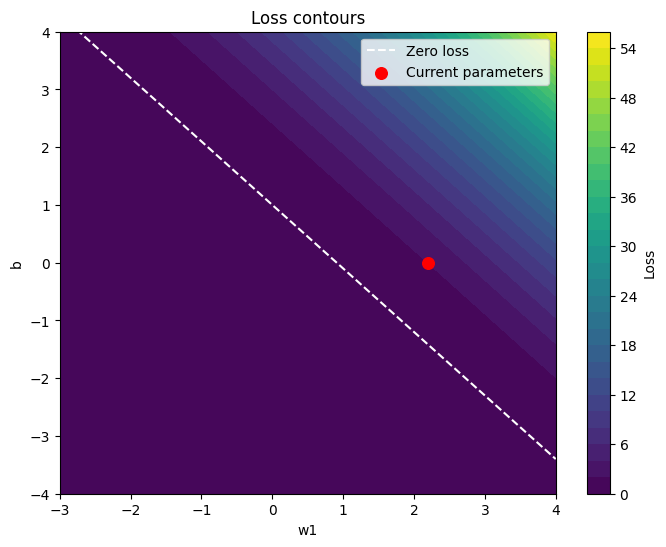

In [36]:
import matplotlib.pyplot as plt

# Create a grid of parameter pairs
w_values = torch.linspace(-3, 4, 150)
b_values = torch.linspace(-4, 4, 150)
W, B = torch.meshgrid(w_values, b_values, indexing="ij")

with torch.no_grad():
    predictions = F.relu(x1.item() * W + B)
    losses = (predictions - y.item()) ** 2

fig, ax = plt.subplots(figsize=(8, 6))

# Color shows the loss at each parameter pair
contour = ax.contourf(W.numpy(), B.numpy(), losses.numpy(),
                     levels=30, cmap="viridis")
fig.colorbar(contour, ax=ax, label="Loss")

# Zero-loss line: b = 1 - 1.1*w1
ax.plot(w_values.numpy(),
        (y.item() - x1.item() * w_values).numpy(),
        "w--", label="Zero loss")

# Mark your current parameters
ax.scatter(w1.item(), b.item(), color="red", s=70,
           label="Current parameters", zorder=5)

ax.set(xlabel="w1", ylabel="b", title="Loss contours",
       xlim=(-3, 4), ylim=(-4, 4))
ax.legend()
plt.show()

# Automatic differentiation


Now let’s look at PyTorch’s automatic differentiation engine, also known as <font color="violet">autograd</font>. PyTorch’s autograd system provides functions to compute gradients in dynamic computational graphs automatically.

<font color="violet">When we carry out computations in PyTorch, it builds a computational graph internally by default if one of its terminal nodes has the `requires_grad` attribute set to `True`.</font> This is useful if we want to compute gradients. Gradients are required when training neural networks via the popular backpropagation algorithm, which can be considered an implementation of the chain rule from calculus for neural networks, illustrated in figure A.8.

<img src="https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/Images/A-8.png" style="filter:invert(1);" width="100%">

Figure above shows <font color="violet"><b>partial derivatives</b>, which measure the rate at which a function changes with respect to <b>one</b> of its variables</font>. 

A <font color="violet">gradient is a vector containing all of the partial derivatives of a multivariate function</font>, a function with more than one variable as input.

If you are not familiar with or don’t remember the partial derivatives, gradients, or chain rule from calculus, don’t worry. 

On a high level, all you need to know is that the chain rule is a way to compute gradients of a loss function given the model’s parameters in a computation graph. 

<!-- This provides the information needed to update each parameter to minimize the loss function, which serves as a proxy for measuring the model’s performance using a method such as gradient descent.  -->

PyTorch’s autograd engine constructs a computational graph in the background by tracking every operation performed on tensors. Then, calling the grad function, we can compute the gradient of the loss concerning the model parameter `w1`, as shown in the following cell:

In [39]:
from torch.autograd import grad

grad_L_w1 = grad(loss, w1, retain_graph=True)   #1
grad_L_b = grad(loss, b, retain_graph=True)

print(grad_L_w1)
print(grad_L_b)

new_w1 = w1 - 0.1 * grad_L_w1[0]
new_b = b - 0.1 * grad_L_b[0]

(tensor([3.1240]),)
(tensor([2.8400]),)


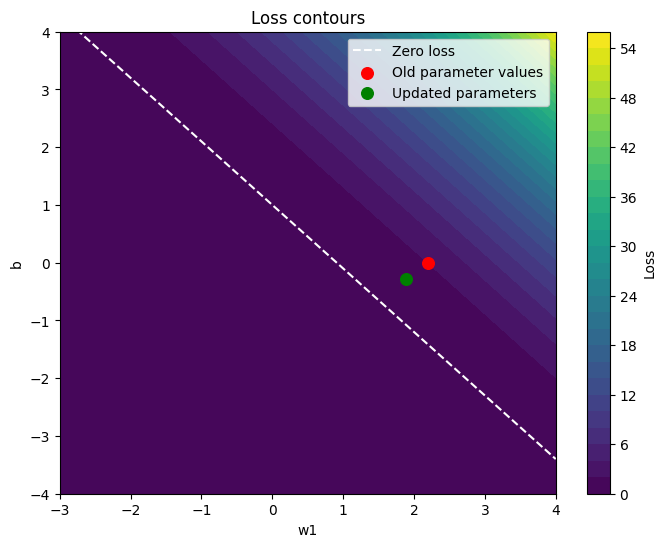

In [41]:
import matplotlib.pyplot as plt

# Create a grid of parameter pairs
w_values = torch.linspace(-3, 4, 150)
b_values = torch.linspace(-4, 4, 150)
W, B = torch.meshgrid(w_values, b_values, indexing="ij")

with torch.no_grad():
    predictions = F.relu(x1.item() * W + B)
    losses = (predictions - y.item()) ** 2

fig, ax = plt.subplots(figsize=(8, 6))

# Color shows the loss at each parameter pair
contour = ax.contourf(W.numpy(), B.numpy(), losses.numpy(),
                     levels=30, cmap="viridis")
fig.colorbar(contour, ax=ax, label="Loss")

# Zero-loss line: b = 1 - 1.1*w1
ax.plot(w_values.numpy(),
        (y.item() - x1.item() * w_values).numpy(),
        "w--", label="Zero loss")

# Mark your current parameters
ax.scatter(w1.item(), b.item(), color="red", s=70,
           label="Old parameter values", zorder=5)


ax.scatter(new_w1.item(), new_b.item(), color="green", s=70,
           label="Updated parameters", zorder=5)

ax.set(xlabel="w1", ylabel="b", title="Loss contours",
       xlim=(-3, 4), ylim=(-4, 4))
ax.legend()
plt.show()

By default, PyTorch destroys the computation graph after calculating the gradients to free memory. However, since we will reuse this computation graph shortly, we set `retain_graph=True` so that it stays in memory.

Here, we have been using the grad function manually, which can be useful for experimentation, debugging, and demonstrating concepts. But, in practice, PyTorch provides even more high-level tools to automate this process. For instance, we can call `.backward` on the loss, and PyTorch will compute the gradients of all the leaf nodes in the graph, which will be stored via the tensors’ `.grad` attributes:

In [15]:
loss.backward()
print(w1.grad)
print(b.grad)

tensor([-0.0898])
tensor([-0.0817])


I've provided you with a lot of information, and you may be overwhelmed by the calculus concepts, but don’t worry. While this calculus jargon is a means to explain PyTorch’s autograd component, all you need to take away is that PyTorch takes care of the calculus for us via the `.backward` method—we won’t need to compute any derivatives or gradients by hand.

# Deep Neural Networks

When implementing a neural network in PyTorch, we can subclass the `torch.nn.Module` class to define our own custom network architecture. 

This `Module` base class provides a lot of functionality, making it easier to build and train models. For instance, it allows us to encapsulate layers and operations and keep track of the model’s parameters.

Within this subclass, we define the network layers in the `__init__` constructor and specify how the layers interact in the forward method. 

The `forward` method describes how the input data passes through the network and comes together as a computation graph. In contrast, the `backward` method, which we typically do not need to implement ourselves, is used during training to compute gradients of the loss function given the model parameters. 

In [ ]:
class NeuralNetwork(torch.nn.Module):
    
    def __init__(self, num_inputs, num_outputs):
        super().__init__()
        self.layers = torch.nn.Sequential(
            # 1st hidden layer
            torch.nn.Linear(num_inputs, 30), torch.nn.ReLU(),
            # 2nd hidden layer
            torch.nn.Linear(30, 20), torch.nn.ReLU(),
            # output layer
            torch.nn.Linear(20, num_outputs),
        )

    def forward(self, x):
        logits = self.layers(x)
        return logits

model = NeuralNetwork(50, 3)
print(model)

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=50, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=3, bias=True)
  )
)


Note that we use the `Sequential` class when we implement the `NeuralNetwork` class. `Sequential` is not required, but it can make our life easier if w e have a series of layers we want to execute in a specific order, as is the case here. This way, after instantiating `self.layers = Sequential(...)` in the `__init__` constructor, we just have to call the `self.layers` instead of calling each layer individually in the `NeuralNetwork`’s `forward` method.

Next, let’s check the total number of trainable parameters of this model:

In [43]:
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total number of trainable model parameters:", num_params)

Total number of trainable model parameters: 2213


Each parameter for which `requires_grad=True` counts as a trainable parameter and will be updated during training.

In the case of our neural network model with the preceding two hidden layers, these trainable parameters are contained in the `torch.nn.Linear` layers. A `Linear` layer multiplies the inputs with a weight matrix and adds a bias vector. This is sometimes referred to as a feedforward or fully connected layer.

Based on the `print(model)` call we executed here, we can see that the first `Linear` layer is at index position 0 in the layers attribute. We can access the corresponding weight parameter matrix as follows:

In [44]:
print(model.layers[0].weight)

Parameter containing:
tensor([[-0.1041,  0.0265, -0.0456,  ..., -0.0818, -0.0317,  0.1267],
        [ 0.1343, -0.0942,  0.0345,  ..., -0.0852, -0.1155, -0.0939],
        [ 0.0329, -0.0755, -0.0213,  ..., -0.0523,  0.0190, -0.1176],
        ...,
        [-0.1088,  0.1158,  0.0407,  ...,  0.1196, -0.0138, -0.0704],
        [-0.1348, -0.1157,  0.1158,  ...,  0.0845,  0.0756,  0.0103],
        [ 0.0232, -0.1160, -0.0517,  ...,  0.0925, -0.0088, -0.1024]],
       requires_grad=True)


Since this large matrix is not shown in its entirety, let’s use the .shape attribute to show its dimensions:

In [45]:
print(model.layers[0].weight.shape)

torch.Size([30, 50])


Similarly, you could access the bias vector via `model.layers[0].bias`.

In [46]:
print(model.layers[0].bias.shape)

torch.Size([30])




The weight matrix here is a 30 × 50 matrix, and we can see that requires_grad is set to `True`, which means its entries are trainable—this is the default setting for weights and biases in `torch.nn.Linear`.

If you execute the preceding code on your computer, the numbers in the weight matrix will likely differ from those shown. The model weights are initialized with small random numbers, which differ each time we instantiate the network. In deep learning, initializing model weights with small random numbers is desired to break symmetry during training. Otherwise, the nodes would be performing the same operations and updates during backpropagation, which would not allow the network to learn complex mappings from inputs to outputs.

However, while we want to keep using small random numbers as initial values for our layer weights, we can make the random number initialization reproducible by seeding PyTorch’s random number generator via `manual_seed`:

In [47]:
torch.manual_seed(123)
model = NeuralNetwork(50, 3)
print(model.layers[0].weight)

Parameter containing:
tensor([[-0.0577,  0.0047, -0.0702,  ...,  0.0222,  0.1260,  0.0865],
        [ 0.0502,  0.0307,  0.0333,  ...,  0.0951,  0.1134, -0.0297],
        [ 0.1077, -0.1108,  0.0122,  ...,  0.0108, -0.1049, -0.1063],
        ...,
        [-0.0787,  0.1259,  0.0803,  ...,  0.1218,  0.1303, -0.1351],
        [ 0.1359,  0.0175, -0.0673,  ...,  0.0674,  0.0676,  0.1058],
        [ 0.0790,  0.1343, -0.0293,  ...,  0.0344, -0.0971, -0.0509]],
       requires_grad=True)


Now that we have spent some time inspecting the `NeuralNetwork` instance, let’s briefly see how it’s used via the forward pass:

In [48]:
torch.manual_seed(123)
X = torch.rand((1, 50))
out = model(X)
print(out)

tensor([[-0.1262,  0.1080, -0.1792]], grad_fn=<AddmmBackward0>)


In the preceding code, we generated a single random training example `X` as a toy input (note that our network expects 50-dimensional feature vectors) and fed it to the model, returning three scores. When we call `model(x)`, it will automatically execute the forward pass of the model.

The forward pass refers to calculating output tensors from input tensors. This involves passing the input data through all the neural network layers, starting from the input layer, through hidden layers, and finally to the output layer.

These three numbers returned here correspond to a score assigned to each of the three output nodes. Notice that the output tensor also includes a `grad_fn` value.

Here, `grad_fn=<AddmmBackward0>` represents the last-used function to compute a variable in the computational graph. In particular, `grad_fn=<AddmmBackward0>` means that the tensor we are inspecting was created via a matrix multiplication and addition operation. PyTorch will use this information when it computes gradients during backpropagation. The `<AddmmBackward0>` part of `grad_fn=<AddmmBackward0>` specifies the operation performed. In this case, it is an Addmm operation. `Addmm` stands for matrix multiplication (`mm`) followed by an addition (`Add`).

If we just want to use a network without training or backpropagation—for example, if we use it for prediction after training—constructing this computational graph for backpropagation can be wasteful as it performs unnecessary computations and consumes additional memory. So, when we use a model for inference (for instance, making predictions) rather than training, the best practice is to use the `torch.no_grad()` context manager. This tells PyTorch that it doesn’t need to keep track of the gradients, which can result in significant savings in memory and computation:

In [49]:
with torch.no_grad():
    out = model(X)
print(out)

tensor([[-0.1262,  0.1080, -0.1792]])


In PyTorch, it’s common practice to code models such that they return the outputs of the last layer (logits) without passing them to a nonlinear activation function. That’s because PyTorch’s commonly used loss functions combine the softmax (or sigmoid for binary classification) operation with the negative log-likelihood loss in a single class. The reason for this is numerical efficiency and stability. So, if we want to compute class-membership probabilities for our predictions, we have to call the softmax function explicitly:

In [50]:
with torch.no_grad():
    out = torch.softmax(model(X), dim=1)
print(out)

tensor([[0.3113, 0.3934, 0.2952]])


The values can now be interpreted as class-membership probabilities that sum up to 1. The values are roughly equal for this random input, which is expected for a randomly initialized model without training.

# Data Loaders

Since deep learning models are typically trained on large datasets, it is often impractical to load the entire dataset into memory at once. 

To address this, PyTorch provides two key classes for data loading: 

1. Dataset 
2. DataLoader

The overall idea behind data loading and how Dataset and DataLoader work in PyTorch is illustrated in figure below:

<img src="https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/Images/A-10.png" style="filter:invert(1);" width="100%">


## 1. `Dataset`

`Dataset` class is an abstract class that we can subclass to create our own datasets. The `Dataset` class is primarily responsible for loading and accessing individual data samples. This is done by implementing the `__len__` and `__getitem__` methods of the class.


Following figure above, we implement a custom Dataset class, which we will use to create a training and a test dataset that we’ll then use to create the data loaders. Let’s start by creating a simple toy dataset of five training examples with two features each. Accompanying the training examples, we also create a tensor containing the corresponding class labels: three examples belong to class 0, and two examples belong to class 1. In addition, we make a test set consisting of two entries. The code to create this dataset is shown in the following listing.

In [53]:
from torch.utils.data import Dataset

class ToyDataset(Dataset):
    def __init__(self, X, y):
        self.features = X
        self.labels = y

    def __getitem__(self, index):        
        one_x = self.features[index]     
        one_y = self.labels[index]       
        return one_x, one_y              

    def __len__(self):
        return self.labels.shape[0]      

X_train = torch.tensor([
    [-1.2, 3.1],
    [-0.9, 2.9],
    [-0.5, 2.6],
    [2.3, -1.1],
    [2.7, -1.5]
])
y_train = torch.tensor([0, 0, 0, 1, 1])

X_test = torch.tensor([[-0.8, 2.8], [2.6, -1.6]])
y_test = torch.tensor([0, 1])

train_ds = ToyDataset(X_train, y_train)
test_ds = ToyDataset(X_test, y_test)

PyTorch requires that class labels start with label 0, and the largest class label value should not exceed the number of output nodes  minus 1 $D_o-1$ (since Python index counting starts at zero). So, if we have class labels 0, 1, 2, 3, and 4, the neural network output layer should consist of five nodes.

Next, we create a custom dataset class, ToyDataset, by subclassing from PyTorch’s Dataset parent class, as shown in the following listing.

The purpose of this custom `ToyDataset` class is to instantiate a PyTorch `DataLoader`. But before we get to this step, let’s briefly go over the general structure of the `ToyDataset` code.

In PyTorch, the three main components of a custom `Dataset` class are: 

* the `__init__` constructor. In the constructor, we set up attributes that we can access later in other methods. These could be file paths, file objects, database connectors, and so on. Since we created a tensor dataset that sits in memory, we simply assign `X` and `y` to these attributes, which are placeholders for our tensor objects.

* the `__getitem__` method. Here, we define instructions for returning exactly one item from the dataset via an `index`. This refers to the features and the class label corresponding to a single training example or test instance. (The data loader will provide this index, which we will cover shortly.)  

* Finally, the `__len__` method contains instructions for retrieving the length of the dataset. Here, we use the `.shape` attribute of a tensor to return the number of rows in the feature array. In the case of the training dataset, we have five rows, which we can double-check:

In [54]:
print(len(train_ds))

5


## 2. `DataLoader`

Now that we’ve defined a PyTorch `Dataset` class we can use for our toy dataset, we can use PyTorch’s `DataLoader` class to sample from it, as shown in the following listing.

`DataLoader` allow us to efficiently load and preprocess data in batches during training.


PyTorch implements a `Dataset` and a `DataLoader` class. The `Dataset` class is used to instantiate objects that define how each data record is loaded. The `DataLoader` handles how the data is shuffled and assembled into batches.


In [55]:
from torch.utils.data import DataLoader

torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_ds,     
    batch_size=2,
    shuffle=True,          
    num_workers=0     
)

test_loader = DataLoader(
    dataset=test_ds,
    batch_size=2,
    shuffle=False,     
    num_workers=0
)

After instantiating the training data loader, we can iterate over it. The iteration over the test_loader works similarly but is omitted for brevity:

In [56]:
for idx, (x, y) in enumerate(train_loader):
    print(f"Batch {idx+1}:", x, y)

Batch 1: tensor([[ 2.3000, -1.1000],
        [-0.9000,  2.9000]]) tensor([1, 0])
Batch 2: tensor([[-1.2000,  3.1000],
        [-0.5000,  2.6000]]) tensor([0, 0])
Batch 3: tensor([[ 2.7000, -1.5000]]) tensor([1])


As we can see based on the preceding output, <font color="violet">the `train_loader` iterates over the training dataset, visiting each training example exactly once. This is known as a training epoch.</font>

Since we seeded the random number generator using `torch.manual_seed(123)` here, you should get the exact same shuffling order of training examples. However, if you iterate over the dataset a second time, you will see that the shuffling order will change. This is desired to prevent deep neural networks from getting caught in repetitive update cycles during training.

We specified a batch size of 2 here, but the third batch only contains a single example. That’s because we have five training examples, and 5 is not evenly divisible by 2. In practice, having a substantially smaller batch as the last batch in a training epoch can disturb the convergence during training. To prevent this, set `drop_last=True`, which will drop the last batch in each epoch, as shown in the following listing.

In [ ]:
train_loader = DataLoader(
    dataset=train_ds,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

Now, iterating over the training loader, we can see that the last batch is omitted:

In [ ]:
for idx, (x, y) in enumerate(train_loader):
    print(f"Batch {idx+1}:", x, y)

Lastly, let’s discuss the setting `num_workers=0` in the DataLoader. This parameter in PyTorch’s `DataLoader` function is crucial for parallelizing data loading and preprocessing. When `num_workers` is set to 0, the data loading will be done in the main process and not in separate worker processes. This might seem unproblematic, but it can lead to significant slowdowns during model training when we train larger networks on a GPU. Instead of focusing solely on the processing of the deep learning model, the CPU must also take time to load and preprocess the data. As a result, the GPU can sit idle while waiting for the CPU to finish these tasks. In contrast, when `num_workers` is set to a number greater than 0, multiple worker processes are launched to load data in parallel, freeing the main process to focus on training your model and better utilizing your system’s resources (figure A.11).

<img src="https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/Images/A-11.png" style="filter:invert(1);" width="100%">

Loading data without multiple workers (setting `num_workers=0`) will create a data loading bottleneck where the model sits idle until the next batch is loaded (left). If multiple workers are enabled, the data loader can queue up the next batch in the background (right).

However, if we are working with very small datasets, setting `num_workers` to 1 or larger may not be necessary since the total training time takes only fractions of a second anyway. So, if you are working with tiny datasets or interactive environments such as Jupyter notebooks, increasing `num_workers` may not provide any noticeable speedup. It may, in fact, lead to some problems. One potential problem is the overhead of spinning up multiple worker processes, which could take longer than the actual data loading when your dataset is small.

Furthermore, for Jupyter notebooks, setting `num_workers` to greater than 0 can sometimes lead to problems related to the sharing of resources between different processes, resulting in errors or notebook crashes. Therefore, it’s essential to understand the tradeoff and make a calculated decision on setting the `num_workers` parameter. When used correctly, it can be a beneficial tool but should be adapted to your specific dataset size and computational environment for optimal results.

In my experience, setting `num_workers=4` usually leads to optimal performance on many real-world datasets, but optimal settings depend on your hardware and the code used for loading a training example defined in the Dataset class.

# Training Loop



**Data**:

$$ D = \{ {\mathbf{X}, \mathbf{Y}} \} $$

where $\mathbf{X} \in R^{I \times D_i}$ and $\mathbf{Y} \in R^{I \times D_o}$

<br/>

Or alternatively we can write

$$ D = \{x_i, y_i\}_{i=1}^I$$

where $x_i \in R^{D_i}$ and $y_i \in R^{D_o}$

<br/>

**Model**:

$$f_{\theta}[x_i]$$

Deep Neural Network

$$
\begin{aligned}
\mathbf{h}_1 &= \textbf{a}\!\left[\boldsymbol{\beta}_0
                 + \boldsymbol{\Omega}_0 \mathbf{x}\right] \\
\mathbf{h}_K &= \textbf{a}\!\left[\boldsymbol{\beta}_{K-1}
                 + \boldsymbol{\Omega}_{K-1}\mathbf{h}_{K-1}\right] \\
\mathbf{y}   &= \boldsymbol{\beta}_K
                 + \boldsymbol{\Omega}_K\mathbf{h}_K
\end{aligned}
$$

and

$$\boldsymbol{\theta = \{\beta_0, \beta_1 \ldots \beta_K, \Omega_0, \Omega_1 \ldots \Omega_K \}}$$

**Forward**:

$$ \hat{y_i} = f_{\theta}[x_i]$$

**Loss**:

$$ L[y, \hat{y}] $$

Least-squares loss:



**Gradient**:

$$ \frac{d}{d\theta} L[y, \hat{~y}~] $$



In [77]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

# Six examples, each with one input feature
inputs = torch.tensor([
    [0.0], [1.0], [2.0], [3.0], [4.0], [5.0]
])

# The correct output for each example: y = 2x + 1
targets = torch.tensor([
    [1.0], [3.0], [5.0], [7.0], [9.0], [11.0]
])

# Pair each input with its correct output
dataset = TensorDataset(inputs, targets)

# Create batches of two examples, keeping their original order
train_loader = DataLoader(dataset, batch_size=2, shuffle=False)

In [78]:
torch.device("cuda" if torch.cuda.is_available() else "cpu")

device(type='cpu')

In [79]:
import torch                 # Load PyTorch
from torch import nn         # Load tools for building neural networks

# Use an NVIDIA GPU if available; otherwise use the CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Sequential sends data through these layers in order
model = nn.Sequential(
    nn.Linear(1, 32),        # Turn 10 input features into 32 values using weights and biases
    nn.ReLU(),                # Replace negative values with 0; keep positive values
    nn.Linear(32, 1),         # Turn 32 values into 3 scores, one per class
).to(device)                  # Move the model to the chosen CPU/GPU

criterion = nn.MSELoss()      # Measure how wrong the class predictions are

# Adam adjusts the model's weights and biases; lr controls the step size
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# An epoch is one complete pass through the training data
for epoch in range(2):      # Repeat training for 10 epochs; epoch runs from 0 to 9
    model.train()             # Enable training behavior; this does not train by itself
    total_loss = 0.0          # Reset the accumulated loss for this epoch
    total_samples = 0         # Reset the number of examples processed

    # A batch is a small group of examples processed together
    for inputs, targets in train_loader:
        inputs = inputs.to(device)    # Move input features to the CPU/GPU
        targets = targets.to(device)  # Move correct class labels to the same device

        optimizer.zero_grad()         # Clear gradients left over from the previous batch
        outputs = model(inputs)       # Forward pass: calculate predicted class scores
        loss = criterion(outputs, targets)  # Compare scores with the correct labels
        loss.backward()               # Calculate how each parameter affects the loss

        for name, param in model.named_parameters():
            print(f"{name}:")
            print("  Value:", param.detach())
            print("  Gradient:", param.grad)

        optimizer.step()              # Use those gradients to adjust the parameters

        # Convert the batch's average loss into a sum over its examples
        total_loss += loss.item() * inputs.size(0)
        total_samples += inputs.size(0)  # Add the number of examples in this batch

    # Print the epoch number and average loss, rounded to four decimal places
    print(f"Epoch {epoch + 1}: loss = {total_loss / total_samples:.4f}")

0.weight:
  Value: tensor([[-0.6319],
        [ 0.4529],
        [-0.3695],
        [ 0.3742],
        [-0.8487],
        [-0.6067],
        [-0.3672],
        [-0.1965],
        [-0.7629],
        [ 0.6548],
        [-0.2358],
        [ 0.3210],
        [ 0.7071],
        [ 0.1863],
        [ 0.2735],
        [ 0.9653],
        [-0.4510],
        [ 0.3168],
        [-0.4449],
        [ 0.7146],
        [ 0.7987],
        [-0.9220],
        [ 0.8536],
        [ 0.4775],
        [ 0.4358],
        [ 0.4117],
        [ 0.8313],
        [-0.1320],
        [-0.8457],
        [-0.2869],
        [-0.7043],
        [ 0.0661]])
  Gradient: tensor([[ 0.0000],
        [ 0.0000],
        [ 0.0000],
        [-0.0118],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000],
        [-0.2445],
        [-0.0192],
        [-0.1036],
        [ 0.0499],
        [ 0.2898],
        [ 0.1992],
        [ 0.3210],
        [-0.4378],
        [ 0.0000],
        [-0.1843],
        [ 0.0000],

# Saving and Loading Models 

Now that we’ve trained our model, let’s see how to save it so we can reuse it later. Here’s the recommended way of saving and loading models in PyTorch:

```python
torch.save(model.state_dict(), "model.pth")
```
The model’s state_dict is a Python dictionary object that maps each layer in the model to its trainable parameters (weights and biases). "model.pth" is an arbitrary filename for the model file saved to disk. We can give it any name and file ending we like; however, `.pth` and `.pt` are the most common conventions.

Once we saved the model, we can restore it from disk:

```python
model = NeuralNetwork(2, 2) 
model.load_state_dict(torch.load("model.pth"))
```

The `torch.load("model.pth")` function reads the file `"model.pth"` and reconstructs the Python dictionary object containing the model’s parameters while `model.load_state_dict()` applies these parameters to the model, effectively restoring its learned state from when we saved it.

The line `model = NeuralNetwork(2, 2)` is not strictly necessary if you execute this code in the same session where you saved a model. However, I included it here to illustrate that we need an instance of the model in memory to apply the saved parameters. Here, the `NeuralNetwork(2, 2)` architecture needs to match the original saved model exactly.



# Question 1. Data Loader

The next step in the Project is to generate the input–target pairs required for training an LLM. 

What do these input–target pairs look like? As we already learned, LLMs are pretrained by predicting the next word in a text. This is shown in figure below: 

<img src="https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/Images/2-12.png" style="filter:invert(1);" width="100%">

Given a text sample, extract input blocks as subsamples that serve as input to the LLM, and the LLM’s prediction task during training is to predict the next word that follows the input block. During training, we mask out all words that are past the target. <font color="violet">Note that the text shown in this figure must undergo tokenization before the LLM can process it</font>; however, <font color="violet">this figure omits the tokenization step only for clarity</font>.

Implement a data loader that fetches the input–target pairs in figure above from the training dataset using a sliding window approach. 

To get started, tokenize the whole “The Verdict” short story using the BPE tokenizer:


In [109]:
import requests
import tiktoken

url = "https://www.gutenberg.org/cache/epub/2600/pg2600.txt"
response = requests.get(url)
response.raise_for_status()
text = response.content.decode("utf-8-sig")

# Remove Gutenberg's header and footer
text = text.split("*** START OF THE PROJECT GUTENBERG EBOOK WAR AND PEACE ***", 1)[1]
text = text.split("*** END OF THE PROJECT GUTENBERG EBOOK WAR AND PEACE ***", 1)[0]
text = text.strip()

# with open("war_and_peace.txt", "w", encoding="utf-8") as f:
#     f.write(text)

print(f"{len(text):,} characters")

tokenizer = tiktoken.get_encoding("gpt2")

enc_text = tokenizer.encode(text)
print(len(enc_text))
enc_text = enc_text[:5000]

3,273,921 characters
916574


One of the easiest and most intuitive ways to create the input–target pairs for the next-word prediction task is to create two variables, $x$ and $y$, where x contains the input tokens and $y$ contains the targets, which are the inputs shifted by 1:

In [110]:
context_size = 4
x = enc_text[:context_size]
y = enc_text[1:context_size+1]
print(f"x: {x}")
print(f"y:        {y}")

x: [16279, 5357, 18468, 11598]
y:        [5357, 18468, 11598, 201]


By processing the inputs along with the targets, which are the inputs shifted by one position, we can create the next-word prediction tasks (see figure 2.12), as follows:

In [111]:
for i in range(1, context_size+1):
    context = enc_text[:i]
    desired = enc_text[i]
    print(context, "---->", desired)

[16279] ----> 5357
[16279, 5357] ----> 18468
[16279, 5357, 18468] ----> 11598
[16279, 5357, 18468, 11598] ----> 201


Everything left of the arrow (---->) refers to the input an LLM would receive, and the token ID on the right side of the arrow represents the target token ID that the LLM is supposed to predict. Let’s repeat the previous code but convert the token IDs into text:

In [112]:
for i in range(1, context_size+1):
    context = enc_text[:i]
    desired = enc_text[i]
    print(tokenizer.decode(context), "---->", tokenizer.decode([desired]))

WAR ---->  AND
WAR AND ---->  PE
WAR AND PE ----> ACE
WAR AND PEACE ----> 


We’ve now created the input–target pairs that we can use for LLM training.

There’s only one more task before we can turn the tokens into embeddings: implementing an efficient data loader that iterates over the input dataset and returns the inputs and targets as PyTorch tensors, which can be thought of as multidimensional arrays. 

In particular, we are interested in returning two tensors: an input tensor containing the text that the LLM sees and a target tensor that includes the targets for the LLM to predict, as depicted in figure 2.13. While the figure shows the tokens in string format for illustration purposes, the code implementation will operate on token IDs directly since the encode method of the BPE tokenizer performs both tokenization and conversion into token IDs as a single step.

<img src="https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/Images/2-13.png" style="filter:invert(1);" width="100%">

To implement efficient data loaders, we collect the inputs in a tensor, x, where each row represents one input context. A second tensor, y, contains the corresponding prediction targets (next words), which are created by shifting the input by one position.

Note  For the efficient data loader implementation, we will use PyTorch’s built-in `Dataset` and `DataLoader` classes. 

The code for the dataset class is shown in the following listing.

In [113]:
import torch
from torch.utils.data import Dataset, DataLoader
class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        #Tokenizes the entire text
        token_ids = tokenizer.encode(txt)
        # token_ids = torch.tensor(token_ids).to(torch.float32)

        #Uses a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    """
    Returns the total number of rows in the dataset
    """
    def __len__(self):
        return len(self.input_ids)

    """
    Returns a single row from the dataset
    """
    def __getitem__(self, idx):         #4
        return self.input_ids[idx], self.target_ids[idx]

    

The `GPTDatasetV1` class is based on the PyTorch `Dataset` class and defines how individual rows are fetched from the dataset, where each row consists of a number of token IDs (based on a `max_length`) assigned to an `input_chunk` tensor. The `target_chunk` tensor contains the corresponding targets. I recommend reading on to see what the data returned from this dataset looks like when we combine the dataset with a PyTorch `DataLoader`—this will bring additional intuition and clarity.

The following code uses the `GPTDatasetV1` to load the inputs in batches via a PyTorch `DataLoader`.

In [114]:
import tiktoken
def create_dataloader_v1(text, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):
    #Initializes the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    #Creates dataset
    dataset = GPTDatasetV1(text, tokenizer, max_length, stride)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,        # Drop the last batch if it is shorter than the specified batch_size to prevent loss spikes during training.
        num_workers=num_workers     # The number of CPU processes to use for preprocessing
    )

    return dataloader


Let’s test the `dataloader` with a batch size of 1 for an LLM with a context size of 4 to develop an intuition of how the `GPTDatasetV1` class from listing 2.5 and the `create_ dataloader_v1` function from listing 2.6 work together:

In [115]:
# with open("the-verdict.txt", "r", encoding="utf-8") as f:
#     raw_text = f.read()

dataloader = create_dataloader_v1(
    text, batch_size=1, max_length=4, stride=1, shuffle=False)
data_iter = iter(dataloader)      #1
first_batch = next(data_iter)
print(first_batch)

[tensor([[16279,  5357, 18468, 11598]]), tensor([[ 5357, 18468, 11598,   201]])]


The `first_batch` variable contains two tensors: the first tensor stores the input token IDs, and the second tensor stores the target token IDs. Since the `max_length` is set to 4, each of the two tensors contains four token IDs. Note that an input size of 4 is quite small and only chosen for simplicity. It is common to train LLMs with input sizes of at least 256.

To understand the meaning of `stride=1`, let’s fetch another batch from this dataset:

In [116]:
second_batch = next(data_iter)
print(second_batch)

[tensor([[ 5357, 18468, 11598,   201]]), tensor([[18468, 11598,   201,   198]])]


If we compare the first and second batches, we can see that the second batch’s token IDs are shifted by one position (for example, the second ID in the first batch’s input is 367, which is the first ID of the second batch’s input). The stride setting dictates the number of positions the inputs shift across batches, emulating a sliding window approach, as demonstrated in figure 2.14.

<img src="https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/Images/2-14.png" style="filter:invert(1);" width="100%">

When creating multiple batches from the input dataset, we slide an input window across the text. If the stride is set to 1, we shift the input window by one position when creating the next batch. If we set the stride equal to the input window size, we can prevent overlaps between the batches.

<font color="violet">To develop more intuition for how the data loader works, try to run it with different settings such as `max_length=2` and `stride=2`, and `max_length=8` and `stride=2`.</font>

Batch sizes of 1, such as we have sampled from the data loader so far, are useful for illustration purposes. If you have previous experience with deep learning, you may know that small batch sizes require less memory during training but lead to more noisy model updates. Just like in regular deep learning, the batch size is a tradeoff and a hyperparameter to experiment with when training LLMs.

Let’s look briefly at how we can use the data loader to sample with a batch size greater than 1:

In [119]:
dataloader = create_dataloader_v1(
    text, batch_size=128, max_length=16, stride=16, shuffle=False
)

data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Inputs:\n", inputs)
print("\nTargets:\n", targets)

Inputs:
 tensor([[16279,  5357, 18468,  ...,   301,   726,    14],
        [   51,   349,   301,  ..., 26714,   201,   198],
        [  201,   198,   220,  ...,   198,   220,   220],
        ...,
        [  220,   220,   220,  ...,  5870, 29485, 42667],
        [  201,   198,   201,  ...,   198,   220,   220],
        [  220,  5870, 29485,  ..., 29922,  3978,   201]])

Targets:
 tensor([[ 5357, 18468, 11598,  ...,   726,    14,    51],
        [  349,   301, 23013,  ...,   201,   198,   201],
        [  198,   220,   220,  ...,   220,   220,   220],
        ...,
        [  220,   220,  5870,  ..., 29485, 42667,   201],
        [  198,   201,   198,  ...,   220,   220,   220],
        [ 5870, 29485, 49090,  ...,  3978,   201,   198]])


Note that we increase the stride to 4 to utilize the data set fully (we don’t skip a single word). This avoids any overlap between the batches since more overlap could lead to increased overfitting.

In [121]:
import torch
import torch.nn.functional as F
from torch import nn

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

vocab_size = tokenizer.n_vocab   # 50257 for the "gpt2" encoding (tokenizer from cell 85)
emb_dim    = 128
num_epochs = 3
DEBUG_FIRST_BATCH = False        # set True once if you want to inspect params/grads

# Token IDs are categorical, so the first layer is a lookup table, not a Linear.
model = nn.Sequential(
    nn.Embedding(vocab_size, emb_dim),   # (B, T) Long  -> (B, T, emb_dim) float
    nn.Linear(emb_dim, emb_dim),         # a small hidden layer
    nn.ReLU(),                           # replace negatives with 0
    nn.Linear(emb_dim, vocab_size),      # -> (B, T, vocab_size): one score per candidate next token
).to(device)

criterion = nn.CrossEntropyLoss()        # classification over the vocabulary
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(num_epochs):
    model.train()
    total_loss  = 0.0
    num_batches = 0

    for batch_idx, (inputs, targets) in enumerate(dataloader):   # inputs, targets: (B, T) Long
        inputs  = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        logits = model(inputs)                                   # (B, T, vocab_size)

        # cross_entropy wants (N, C) logits and (N,) targets, so flatten batch+time
        loss = criterion(logits.flatten(0, 1), targets.flatten())
        loss.backward()

        if DEBUG_FIRST_BATCH and epoch == 0 and batch_idx == 0:
            for name, param in model.named_parameters():
                print(f"{name}: value={param.detach().flatten()[:3]}... "
                      f"grad={param.grad.flatten()[:3]}...")

        optimizer.step()

        total_loss  += loss.item()
        num_batches += 1

    print(f"Epoch {epoch + 1}: loss = {total_loss / num_batches:.4f}")


Epoch 1: loss = 6.2261
Epoch 2: loss = 6.0545
Epoch 3: loss = 14.8472


# Question 2. Fitting the Doppler Function

The **Doppler function**

$$f(x) = \sqrt{x(1-x)}\;\sin\!\left(\frac{2.1\pi}{x + 0.05}\right), \qquad x \in [0, 1]$$

is a standard stress test for regression. Its oscillations are very fast near
`x = 0` and slow down toward `x = 1`, so there is **no single length scale** that
works across the whole domain. 

A model that resolves the wiggles on the left tends to overfit the smooth region on the right, and a model that is too small or trained too briefly collapses to a nearly flat line through the mean.

Your job is to fit it as well as you can.


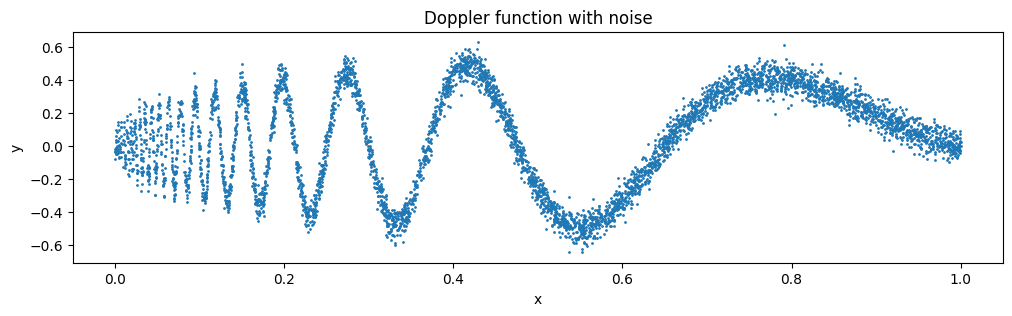

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

def make_doppler(n_samples=3000, noise=0.05, random_state=None):
    rng = np.random.default_rng(random_state)
    x = rng.uniform(0, 1, n_samples)
    y = np.sqrt(x * (1 - x)) * np.sin(2.1 * np.pi / (x + 0.05))
    y += rng.normal(scale=noise, size=n_samples)
    X = x.reshape(-1, 1)                 # (n, 1)
    return X, y.reshape(-1, 1)           # (n, 1)


X, y = make_doppler(n_samples=5000, noise=0.05, random_state=42)

plt.figure(figsize=(12, 3))
plt.scatter(X, y, s=1);
plt.xlabel("x"); plt.ylabel("y"); plt.title("Doppler function with noise");

## 2.1. Implement a data loader

Using the `torch.utils.data.Dataset` and `torch.utils.data.DataLoader` classes, implement data loaders that returns batches of input–target pairs for the Doppler function. 

There are two data loaders to implement: one for training and one for testing.

Create training and testing inputs of 1000 and 200 samples, respectively by using `torch.rand(n_samples)` to sample uniformly from the interval `[0, 1]`.

The target tensor should be computed by applying the Doppler function to the input tensor.

## 2.2. Implement a model 

Implement either `torch.nn.Sequential` or a `torch.nn.Module` subclass — that maps one input to one output.

You may choose any number of layers and nodes in each layer. Just keep in mind that the training time will increase with the number of parameters in the model.

Use `nn.ReLU()` activation functions for the hidden layers. The output layer should have no activation function.

## 2.3. Training Loop 

Implement a training loop over `train_loader`: forward pass, `MSELoss`, `loss.backward()`, `optimizer.step()`, `optimizer.zero_grad()`, with the optimizer bound to **your model's** parameters. Print the average training loss in the training loop but do not print the loss for every epoch. 

## 2.4 Evaluate using the test set

Evaluate the model on the test set using `test_loader`. Compute the average loss over the test set and print it.

## 2.4. Plot your model's prediction 

Plot your model's prediction as a smooth curve over the range `[0, 1]`, drawn on top of a scatter of the training data.


- If your prediction is a flat line, check that (a) the optimizer is bound to your
  model, (b) the training loss actually decreases, (c) you normalized the inputs.

- Watch for overfitting the noise near `x = 0`; compare training vs test MSE.

In [ ]:
import numpy as np

def make_doppler(n_samples=3000, noise=0.05, random_state=None):
    rng = np.random.default_rng(random_state)
    x = rng.uniform(0, 1, n_samples)
    y = np.sqrt(x * (1 - x)) * np.sin(2.1 * np.pi / (x + 0.05))
    y += rng.normal(scale=noise, size=n_samples)
    X = x.reshape(-1, 1)                 # (n, 1)
    return X, y.reshape(-1, 1)           # (n, 1)


X, y = make_doppler(n_samples=3000, noise=0.05, random_state=seed)

plt.figure(figsize=(12, 1.5))
plt.scatter(X, y, cmap="viridis", s=1);

model = nn.Sequential(
    nn.Linear(1, 128),        # Turn 2 input features into 32 values using weights and biases
    nn.ReLU(),                # Replace negative values with 0; keep positive values
    nn.Linear(128, 128),         # Turn 32 values into 1 output value
    nn.ReLU(),                # Replace negative values with 0; keep positive values
    nn.Linear(128, 1),         # Turn 32 values into 1 output value
).to(device)                  # Move the model to the chosen CPU/GPU

dataset = TensorDataset(torch.tensor(X, dtype=torch.float32).unsqueeze(1),
                        torch.tensor(y, dtype=torch.float32).unsqueeze(1))

train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

criterion = nn.MSELoss()      # Measure how wrong the predictions are
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)

from tqdm import tqdm

for epoch in tqdm(range(1000)):      # Repeat training for 2 epochs; epoch runs from 0 to 1
    model.train()             # Enable training behavior; this does not train by itself
    total_loss = 0.0          # Reset the accumulated loss for this epoch
    total_samples = 0         # Reset the number of examples processed

    # A batch is a small group of examples processed together
    for inputs, targets in train_loader:
        inputs = inputs.to(device)    # Move input features to the CPU/GPU
        targets = targets.to(device)  # Move correct class labels to the same device

        optimizer.zero_grad()         # Clear gradients left over from the previous batch
        outputs = model(inputs)       # Forward pass: calculate predicted class scores
        loss = criterion(outputs, targets)  # Compare scores with the correct labels
        loss.backward()               # Calculate how each parameter affects the loss

        optimizer.step()              # Use those gradients to adjust the parameters

        # Convert the batch's average loss into a sum over its examples
        total_loss += loss.item() * inputs.size(0)
        total_samples += inputs.size(0)  # Add the number of examples in this batch

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}: loss = {total_loss / total_samples:.4f}")
    # Print the epoch number and average loss, rounded to four decimal places
    # print(f"Epoch {epoch + 1}: loss = {total_loss / total_samples:.4f}")